## Project Introduction

In [8]:
# Pharmaceutical Sales & Prescription Analysis

## Objective

The objective of this project is to analyze pharmaceutical sales and prescription data to identify business trends, improve inventory planning, evaluate sales performance, and support data-driven decision making.

## Tools Used

• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn

## Dataset

50000 Pharmaceutical Sales Records

## KPIs

• Revenue
• Profit
• Prescriptions
• Units Sold
• Profit Margin

SyntaxError: invalid character '•' (U+2022) (397801928.py, line 9)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')

pd.set_option('display.max_columns',None)

## Load Dataset

In [2]:
df = pd.read_csv("pharmaceutical_sales_prescription_50000_rows.csv")

df.head()

,Transaction_ID,Date,Year,Month,Quarter,Drug_Name,Drug_Category,State,City,Sales_Rep,Customer_Type,Doctor_Specialty,Patient_Gender,Patient_Age,Prescriptions,Units_Sold,Unit_Price,Discount_%,Revenue,Cost,Profit
0,1,2023-08-17,2023,August,3,Lipitor,Cardiovascular,Uttar Pradesh,Lucknow,Arjun,Pharmacy,Orthopedics,Male,72,160,181,1478,2,262167.64,185145.92,77021.72
1,2,2023-03-07,2023,March,1,Lipitor,Cardiovascular,Delhi,New Delhi,Sneha,Pharmacy,Gastroenterology,Female,46,131,150,1767,7,246496.50,125079.74,121416.76
2,3,2025-07-08,2025,July,3,Salbutamol,Respiratory,Telangana,Hyderabad,Rohit,Hospital,General Medicine,Female,31,434,424,331,10,126309.60,78101.27,48208.33
3,4,2023-07-09,2023,July,3,Pantoprazole,Gastro,Delhi,New Delhi,Meera,Clinic,Orthopedics,Male,66,203,237,759,3,174486.51,126676.49,47810.02
4,5,2023-06-11,2023,June,2,Montelukast,Respiratory,Telangana,Hyderabad,Rahul,Pharmacy,General Medicine,Female,28,444,480,595,2,279888.00,195160.34,84727.66


## Dataset Exploration

In [3]:
## Shape
df.shape

(50000, 21)

In [4]:
## Last 5 Rows
df.tail()

,Transaction_ID,Date,Year,Month,Quarter,Drug_Name,Drug_Category,State,City,Sales_Rep,Customer_Type,Doctor_Specialty,Patient_Gender,Patient_Age,Prescriptions,Units_Sold,Unit_Price,Discount_%,Revenue,Cost,Profit
49995,49996,2023-03-12,2023,March,1,Vitamin D3,Supplements,Telangana,Hyderabad,Anita,Clinic,Pulmonology,Male,25,129,156,343,10,48157.20,36609.70,11547.50
49996,49997,2024-02-27,2024,February,1,Clopidogrel,Cardiovascular,Gujarat,Ahmedabad,Anita,Pharmacy,Pulmonology,Male,55,321,339,1745,12,520568.40,371577.83,148990.57
49997,49998,2025-11-10,2025,November,4,Telmisartan,Cardiovascular,Odisha,Bhubaneswar,Sneha,Pharmacy,Orthopedics,Female,81,141,175,842,12,129668.00,75511.30,54156.70
49998,49999,2025-05-08,2025,May,2,Amoxicillin,Antibiotic,Rajasthan,Jaipur,Pooja,Clinic,Neurology,Female,47,395,403,758,5,290200.30,150992.82,139207.48
49999,50000,2025-12-25,2025,December,4,Linezolid,Antibiotic,Telangana,Hyderabad,Karan,Clinic,Gastroenterology,Female,67,393,407,2216,12,793682.56,493369.14,300313.42


In [5]:
## Column Names
df.columns

Index(['Transaction_ID', 'Date', 'Year', 'Month', 'Quarter', 'Drug_Name',
       'Drug_Category', 'State', 'City', 'Sales_Rep', 'Customer_Type',
       'Doctor_Specialty', 'Patient_Gender', 'Patient_Age', 'Prescriptions',
       'Units_Sold', 'Unit_Price', 'Discount_%', 'Revenue', 'Cost', 'Profit'],
      dtype='object')

In [6]:
## Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    50000 non-null  int64  
 1   Date              50000 non-null  object 
 2   Year              50000 non-null  int64  
 3   Month             50000 non-null  object 
 4   Quarter           50000 non-null  int64  
 5   Drug_Name         50000 non-null  object 
 6   Drug_Category     50000 non-null  object 
 7   State             50000 non-null  object 
 8   City              50000 non-null  object 
 9   Sales_Rep         50000 non-null  object 
 10  Customer_Type     50000 non-null  object 
 11  Doctor_Specialty  50000 non-null  object 
 12  Patient_Gender    50000 non-null  object 
 13  Patient_Age       50000 non-null  int64  
 14  Prescriptions     50000 non-null  int64  
 15  Units_Sold        50000 non-null  int64  
 16  Unit_Price        50000 non-null  int64 

In [7]:
## Statistical Summary
df.describe()

,Transaction_ID,Year,Quarter,Patient_Age,Prescriptions,Units_Sold,Unit_Price,Discount_%,Revenue,Cost,Profit
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000
mean,25000.500000,2024.001000,2.50316,51.479140,260.502440,285.492000,862.951800,5.547860,2.330359e+05,1.492726e+05,83763.230529
std,14433.901067,0.815066,1.11745,19.599814,138.975554,140.628517,615.419634,4.033811,2.183810e+05,1.424626e+05,82386.031109
min,1.000000,2023.000000,1.00000,18.000000,20.000000,10.000000,80.000000,0.000000,1.484100e+03,9.247600e+02,496.700000
25%,12500.750000,2023.000000,2.00000,35.000000,140.000000,165.000000,412.000000,2.000000,8.096746e+04,5.102460e+04,27880.737500
50%,25000.500000,2024.000000,3.00000,52.000000,260.000000,285.000000,689.000000,5.000000,1.637182e+05,1.038548e+05,57149.050000
75%,37500.250000,2025.000000,3.00000,68.000000,381.000000,406.000000,1158.000000,10.000000,3.105530e+05,1.980150e+05,110447.540000
max,50000.000000,2025.000000,4.00000,85.000000,500.000000,560.000000,3200.000000,12.000000,1.647432e+06,1.197014e+06,735330.210000


In [8]:
## Missing Values
df.isnull().sum()

Transaction_ID      0
Date                0
Year                0
Month               0
Quarter             0
Drug_Name           0
Drug_Category       0
State               0
City                0
Sales_Rep           0
Customer_Type       0
Doctor_Specialty    0
Patient_Gender      0
Patient_Age         0
Prescriptions       0
Units_Sold          0
Unit_Price          0
Discount_%          0
Revenue             0
Cost                0
Profit              0
dtype: int64

In [9]:
## Duplicate Records
df.duplicated().sum()

np.int64(0)

## Data Cleaning

In [10]:
## Convert Date
df['Date']=pd.to_datetime(df['Date'])

In [11]:
## Check Missing Values Again
df.isnull().sum()

Transaction_ID      0
Date                0
Year                0
Month               0
Quarter             0
Drug_Name           0
Drug_Category       0
State               0
City                0
Sales_Rep           0
Customer_Type       0
Doctor_Specialty    0
Patient_Gender      0
Patient_Age         0
Prescriptions       0
Units_Sold          0
Unit_Price          0
Discount_%          0
Revenue             0
Cost                0
Profit              0
dtype: int64

## Data Validation

In [12]:
## Revenue cannot be negative
df=df[df['Revenue']>=0]

In [13]:
## Profit cannot be extremely invalid
df=df[df['Profit']>-100000]

In [14]:
## Units Sold
df=df[df['Units_Sold']>0]

In [15]:
## Prescriptions
df=df[df['Prescriptions']>0]

## Feature Engineering

In [16]:
## Profit Margin
df['Profit Margin %']=round(df['Profit']/df['Revenue']*100,2)

In [17]:
## Revenue Per Prescription
df['Revenue Per Prescription']=df['Revenue']/df['Prescriptions']

In [18]:
## Cost Per Unit
df['Cost Per Unit']=df['Cost']/df['Units_Sold']

In [19]:
## Revenue Per Unit
df['Revenue Per Unit']=df['Revenue']/df['Units_Sold']

In [20]:
## Age Group
bins=[0,18,35,50,65,100]

labels=['Child','Young Adult','Adult','Senior Adult','Senior']

df['Age Group']=pd.cut(df['Patient_Age'],bins=bins,labels=labels)

In [21]:
## Season
season={
1:'Winter',2:'Winter',12:'Winter',
3:'Spring',4:'Spring',5:'Spring',
6:'Summer',7:'Summer',8:'Summer',
9:'Autumn',10:'Autumn',11:'Autumn'
}

df['Season']=df['Date'].dt.month.map(season)

In [22]:
## Day Name
df['Day']=df['Date'].dt.day_name()

In [23]:
## Month Number
df['Month Number']=df['Date'].dt.month

In [24]:
## Week Number
df['Week']=df['Date'].dt.isocalendar().week

## Exploratory Data Analysis (EDA)

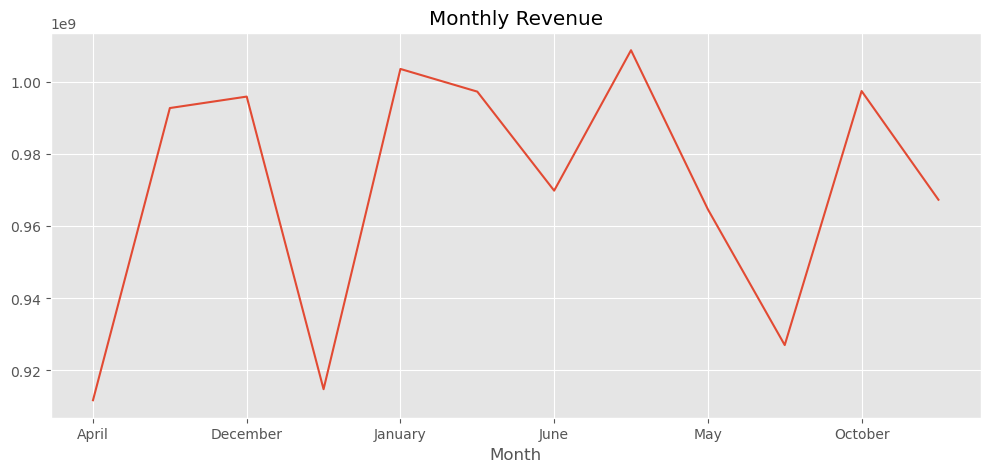

In [25]:
## Revenue Trend
monthly=df.groupby('Month')['Revenue'].sum()

monthly.plot(figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

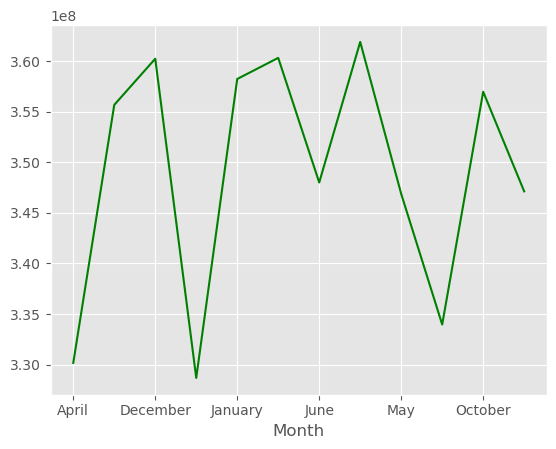

In [26]:
## Profit Trend
monthly=df.groupby('Month')['Profit'].sum()

monthly.plot(color='green')
plt.show()

<Axes: xlabel='Drug_Name'>

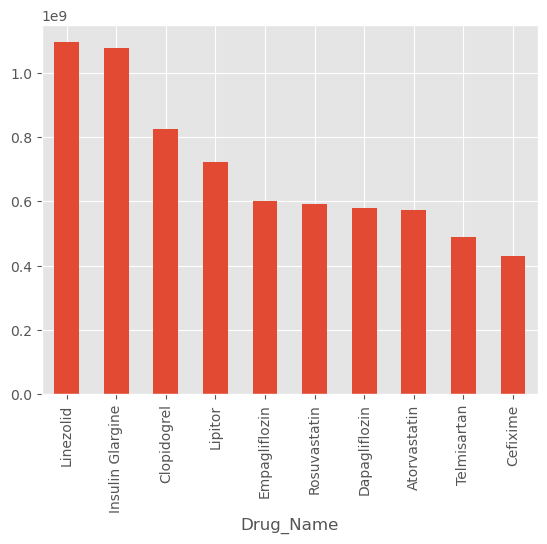

In [27]:
## Top 10 Drugs
top=df.groupby('Drug_Name')['Revenue'].sum()

top.sort_values(ascending=False).head(10).plot.bar()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Cardiovascular'),
  Text(1, 0, 'Respiratory'),
  Text(2, 0, 'Gastro'),
  Text(3, 0, 'Psychiatry'),
  Text(4, 0, 'Supplements'),
  Text(5, 0, 'Diabetes'),
  Text(6, 0, 'Pain Relief'),
  Text(7, 0, 'Antibiotic'),
  Text(8, 0, 'Immunology'),
  Text(9, 0, 'Neurology'),
  Text(10, 0, 'Endocrine'),
  Text(11, 0, 'Allergy')])

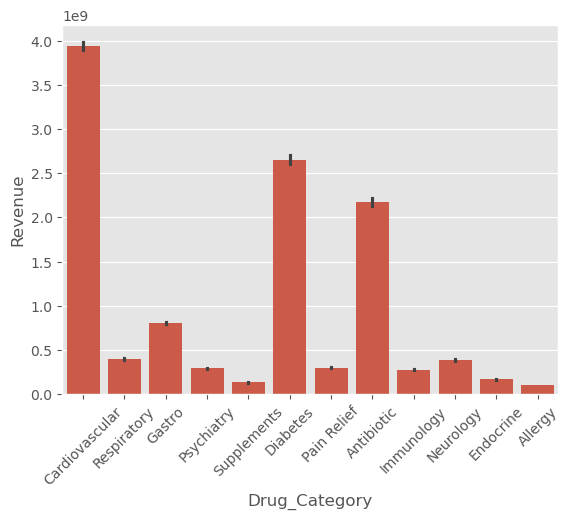

In [28]:
## Drug Category Revenue
sns.barplot(
data=df,
x='Drug_Category',
y='Revenue',
estimator=sum
)

plt.xticks(rotation=45)

<Axes: ylabel='State'>

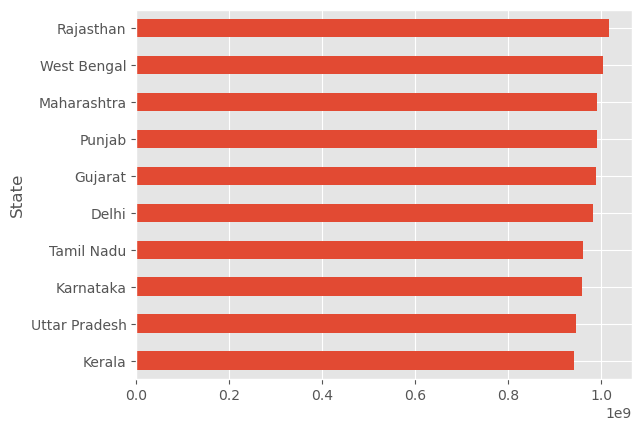

In [29]:
## Top States
state=df.groupby('State')['Revenue'].sum()

state.sort_values().tail(10).plot.barh()

<Axes: ylabel='City'>

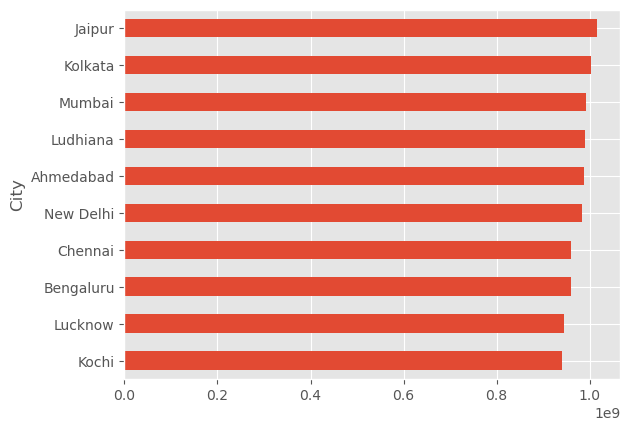

In [30]:
## Top Cities
city=df.groupby('City')['Revenue'].sum()

city.sort_values().tail(10).plot.barh()

<Axes: ylabel='Sales_Rep'>

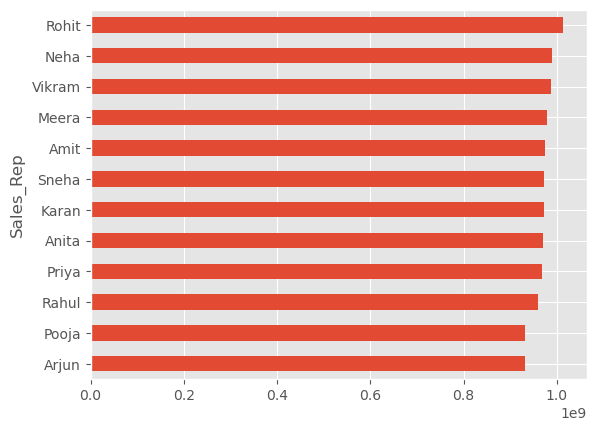

In [59]:
## Sales Representative Performance
rep=df.groupby('Sales_Rep')['Revenue'].sum()

rep.sort_values().tail(15).plot.barh()

<Axes: xlabel='Customer_Type', ylabel='count'>

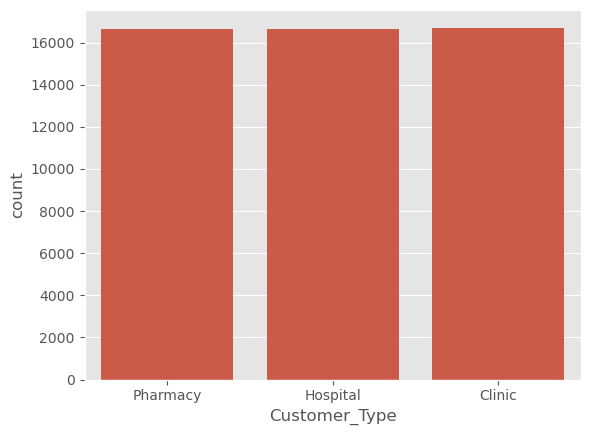

In [60]:
## Customer Type
sns.countplot(data=df,x='Customer_Type')

<Axes: xlabel='count', ylabel='Doctor_Specialty'>

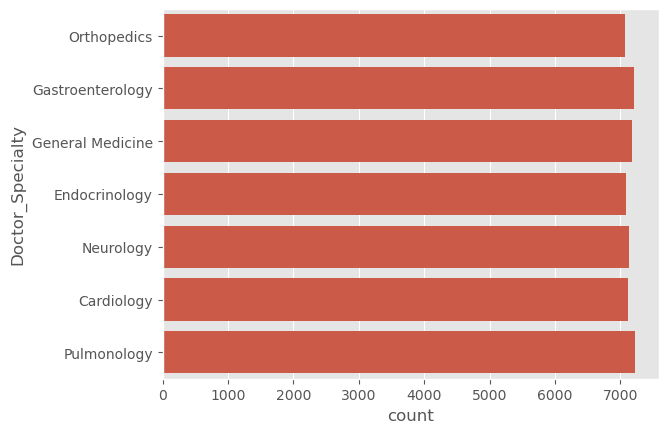

In [61]:
## Doctor Specialty
sns.countplot(
data=df,
y='Doctor_Specialty'
)

<Axes: xlabel='Patient_Gender', ylabel='count'>

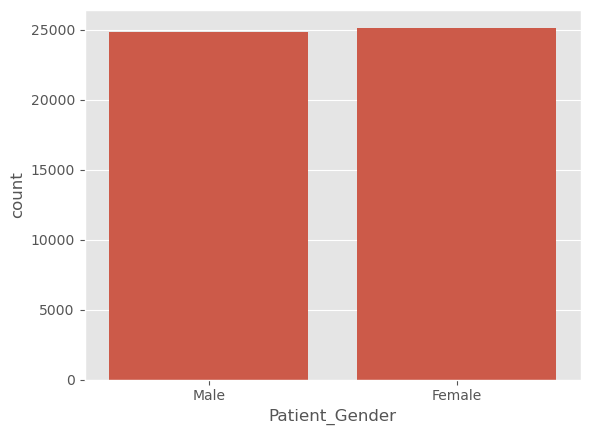

In [62]:
## Gender Distribution
sns.countplot(
data=df,
x='Patient_Gender'
)

<Axes: xlabel='Patient_Age', ylabel='Count'>

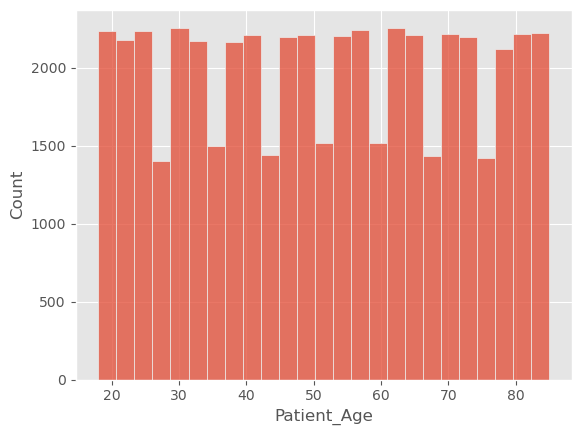

In [63]:
## Age Distribution
sns.histplot(df['Patient_Age'],bins=25)


<Axes: xlabel='Revenue', ylabel='Count'>

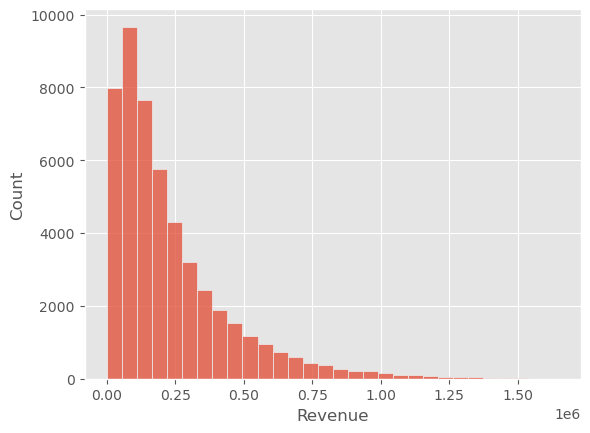

In [64]:
## Revenue Distribution
sns.histplot(df['Revenue'],bins=30)

<Axes: xlabel='Profit', ylabel='Count'>

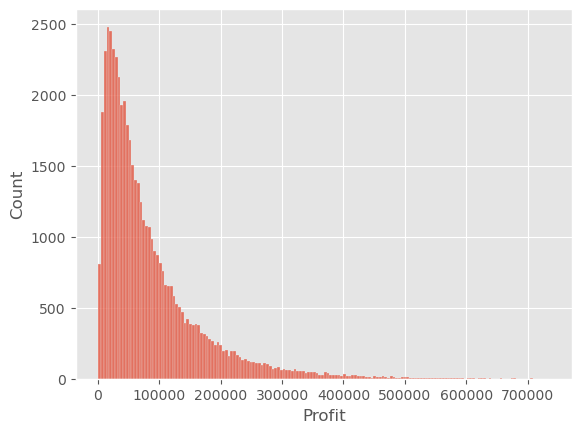

In [65]:
## Profit Distribution
sns.histplot(df['Profit'])

<Axes: xlabel='Revenue', ylabel='Profit'>

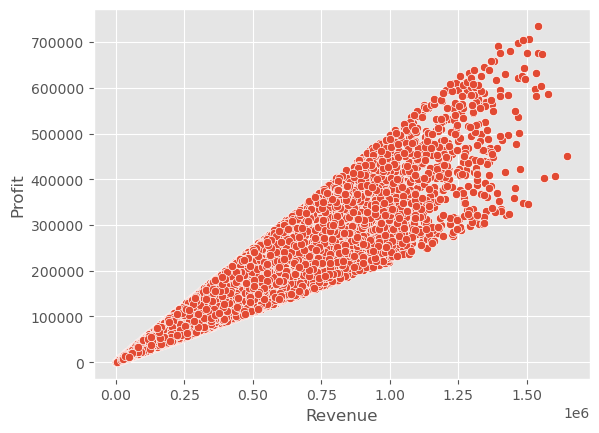

In [66]:
## Revenue vs Profit
sns.scatterplot(
data=df,
x='Revenue',
y='Profit'
)

<Axes: xlabel='Discount_%', ylabel='Revenue'>

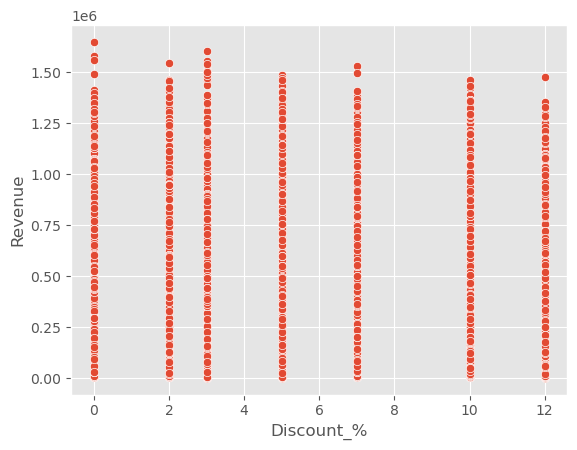

In [67]:
## Discount vs Revenue
sns.scatterplot(
data=df,
x='Discount_%',
y='Revenue'
)

<Axes: >

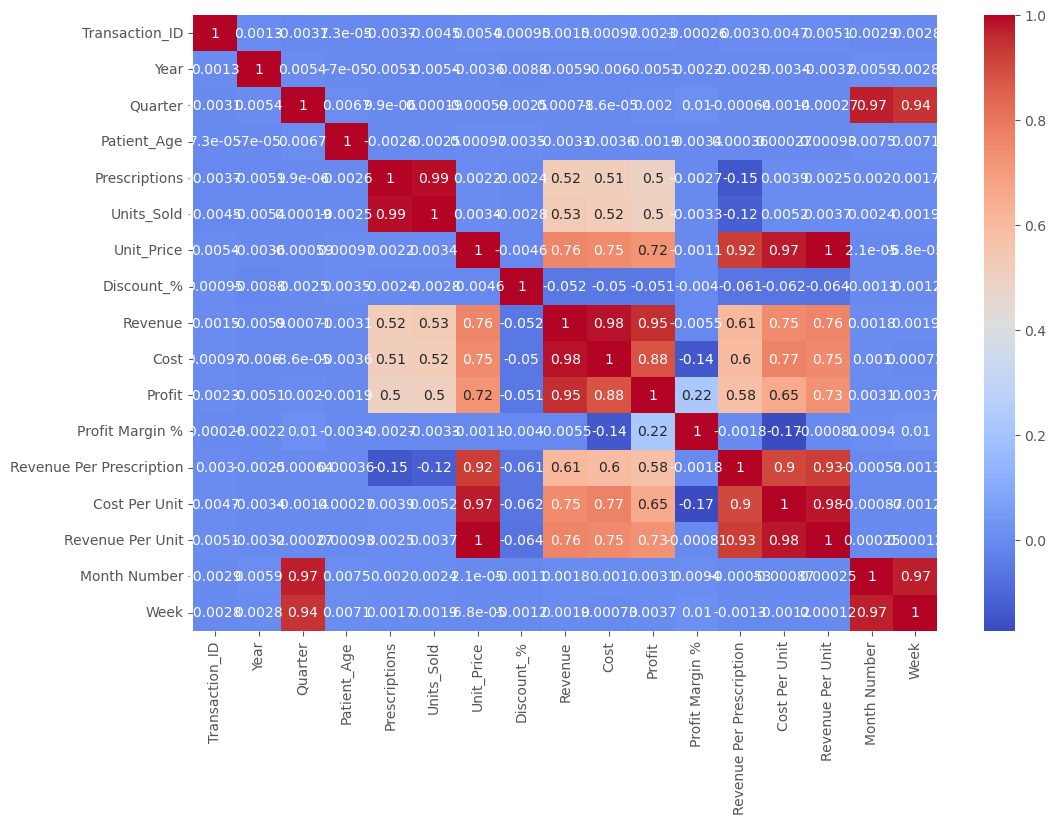

In [68]:
## Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
df.select_dtypes(np.number).corr(),
annot=True,
cmap='coolwarm'
)

<Axes: xlabel='Revenue'>

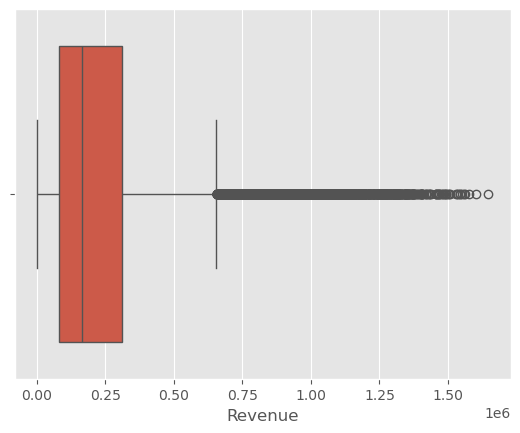

In [69]:
## Boxplot Revenue
sns.boxplot(
x=df['Revenue']
)

<Axes: xlabel='Profit'>

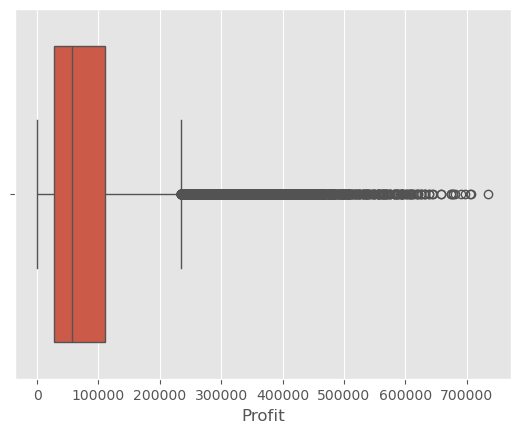

In [70]:
## Boxplot Profit
sns.boxplot(
x=df['Profit']
)

<Axes: xlabel='Month'>

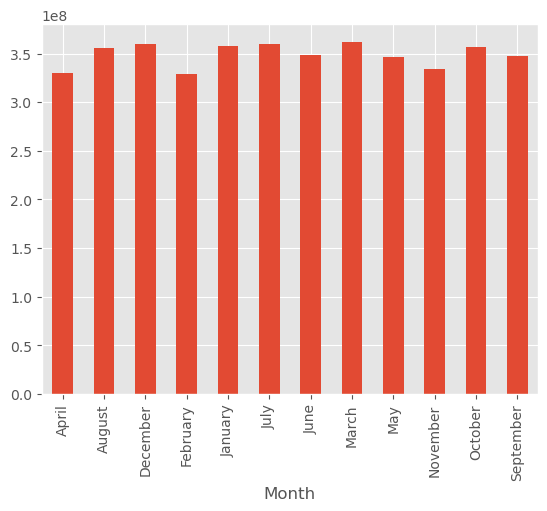

In [71]:
## Monthly Profit
df.groupby('Month')['Profit'].sum().plot.bar()

<Axes: xlabel='Quarter'>

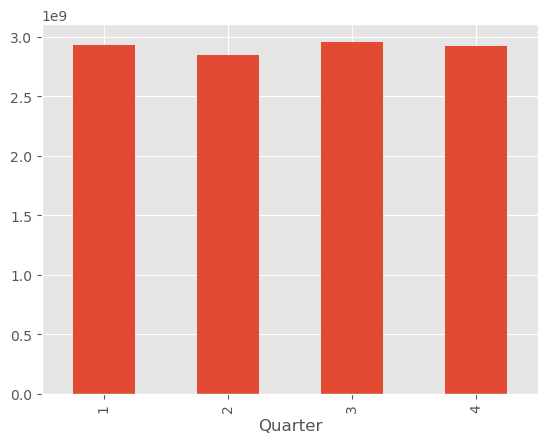

In [72]:
## Quarterly Revenue
df.groupby('Quarter')['Revenue'].sum().plot.bar()

<Axes: xlabel='Customer_Type', ylabel='Revenue'>

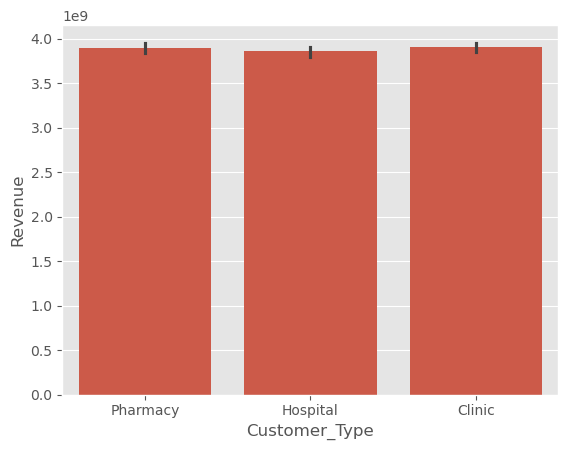

In [73]:
## Revenue by Customer Type
sns.barplot(
data=df,
x='Customer_Type',
y='Revenue',
estimator=sum
)

<Axes: xlabel='Patient_Gender', ylabel='Revenue'>

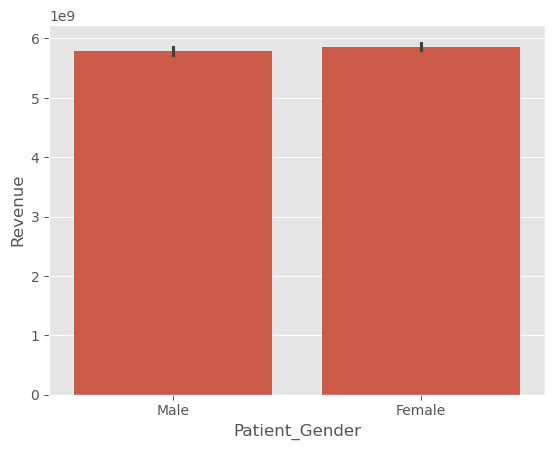

In [74]:
## Revenue by Gender
sns.barplot(
data=df,
x='Patient_Gender',
y='Revenue',
estimator=sum
)

<Axes: xlabel='Drug_Name'>

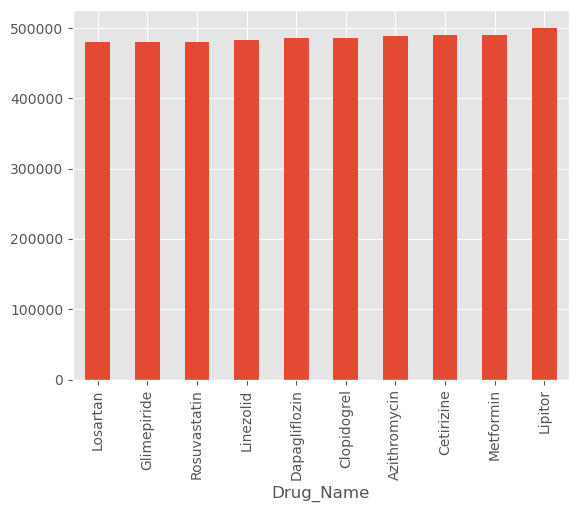

In [75]:
## Units Sold by Drug
drug=df.groupby('Drug_Name')['Units_Sold'].sum()

drug.sort_values().tail(10).plot.bar()

<Axes: xlabel='Profit Margin %', ylabel='Count'>

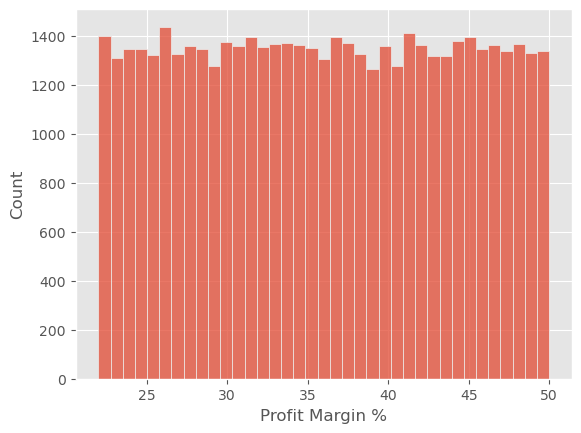

In [76]:
## Profit Margin Distribution
sns.histplot(df['Profit Margin %'])

<Axes: xlabel='Season', ylabel='Revenue'>

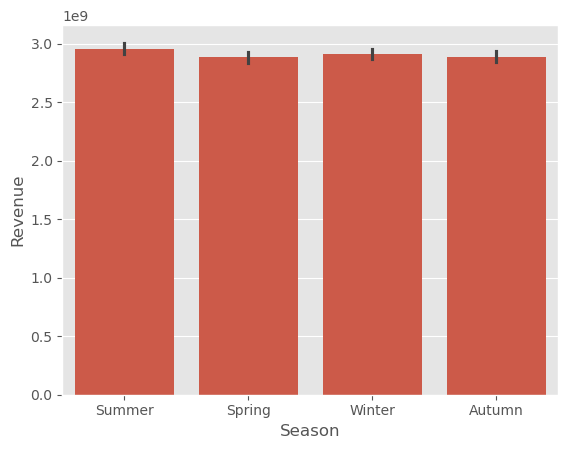

In [77]:
## Season Analysis
sns.barplot(
data=df,
x='Season',
y='Revenue',
estimator=sum
)

## Statistical Analysis

In [78]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Transaction_ID,50000.0,25000.5,1.0,12500.75,25000.5,37500.25,50000.0,14433.901067
Date,50000,2024-07-01 11:07:33.312000256,2023-01-01 00:00:00,2023-10-02 00:00:00,2024-07-02 00:00:00,2025-04-02 00:00:00,2025-12-31 00:00:00,NaN
Year,50000.0,2024.001,2023.0,2023.0,2024.0,2025.0,2025.0,0.815066
Quarter,50000.0,2.50316,1.0,2.0,3.0,3.0,4.0,1.11745
Patient_Age,50000.0,51.47914,18.0,35.0,52.0,68.0,85.0,19.599814
Prescriptions,50000.0,260.50244,20.0,140.0,260.0,381.0,500.0,138.975554
Units_Sold,50000.0,285.492,10.0,165.0,285.0,406.0,560.0,140.628517
Unit_Price,50000.0,862.9518,80.0,412.0,689.0,1158.0,3200.0,615.419634
Discount_%,50000.0,5.54786,0.0,2.0,5.0,10.0,12.0,4.033811
Revenue,50000.0,233035.866419,1484.1,80967.46,163718.235,310552.95,1647432.0,218381.008573


## Business Insights

In [79]:
# ==========================================
# Business Insights & Summary Findings
# ==========================================

print("="*80)
print("              PHARMACEUTICAL SALES & PRESCRIPTION ANALYSIS")
print("                     BUSINESS INSIGHTS SUMMARY")
print("="*80)

print("""

1. Revenue vs Profit
--------------------
• Revenue and Profit show a very strong positive correlation.
• As revenue increases, profit increases almost proportionally.
• High-revenue transactions generate significantly higher profits.

2. Discount Analysis
--------------------
• Discount percentages range from 0% to 12%.
• Revenue remains relatively stable across different discount levels.
• Moderate discounts do not negatively impact total revenue.

3. Correlation Analysis
-----------------------
• Revenue has strong positive correlation with:
    - Profit
    - Cost
    - Units Sold
    - Unit Price

• Profit Margin has relatively weak correlation with Revenue,
  indicating profitability depends on pricing strategy rather than
  sales volume alone.

4. Outlier Detection
--------------------
• Revenue and Profit boxplots indicate several high-value transactions.
• These outliers represent premium drug sales or bulk hospital orders.
• They should be monitored separately during business reporting.

5. Monthly Performance
----------------------
• Monthly profit remains fairly consistent throughout the year.
• No major seasonal decline is observed.
• Business performance is stable across all months.

6. Quarterly Performance
------------------------
• Quarterly revenue is evenly distributed.
• Quarter 3 shows slightly higher revenue.
• No significant quarterly fluctuations exist.

7. Customer Type Analysis
-------------------------
• Pharmacy, Hospital and Clinic generate almost equal revenue.
• Customer portfolio is well balanced.
• No single customer segment dominates the business.

8. Gender Analysis
------------------
• Male and Female patients contribute nearly identical revenue.
• Sales performance is not dependent on patient gender.

9. Drug Performance
-------------------
• Several drugs consistently record the highest unit sales.
• Lipitor appears among the top-selling medicines.
• Top-selling drugs should receive priority in inventory planning.

10. Profit Margin Distribution
------------------------------
• Profit margins range approximately between 22% and 50%.
• Average profit margin is around 36%.
• Distribution is balanced without extreme skewness.

11. Seasonal Analysis
---------------------
• Revenue remains stable across Spring, Summer, Autumn and Winter.
• Seasonal demand variation is minimal.
• Business demand is consistent throughout the year.

======================================================================
FINAL CONCLUSION
======================================================================

The pharmaceutical business demonstrates strong and stable financial
performance.

Key findings include:

✔ Strong positive relationship between Revenue and Profit.
✔ Consistent monthly and quarterly business growth.
✔ Balanced revenue across all customer types.
✔ Equal contribution from male and female patients.
✔ Stable seasonal demand.
✔ Healthy average profit margin (~36%).
✔ Presence of high-value transactions requiring monitoring.
✔ Top-selling medicines contribute significantly to total sales.

Business Recommendations
------------------------
• Focus inventory planning on top-selling drugs.
• Monitor high-value transactions separately.
• Optimize discount strategies without reducing profitability.
• Maintain balanced relationships across Pharmacy, Hospital and Clinic.
• Continue pricing strategies that preserve healthy profit margins.
• Use predictive analytics to forecast demand and optimize stock levels.

Overall Business Health : EXCELLENT
Revenue Stability        : HIGH
Profitability            : HIGH
Sales Growth Potential   : HIGH

""")

print("="*80)
print("                END OF PHARMACEUTICAL SALES ANALYSIS")
print("="*80)

              PHARMACEUTICAL SALES & PRESCRIPTION ANALYSIS
                     BUSINESS INSIGHTS SUMMARY


1. Revenue vs Profit
--------------------
• Revenue and Profit show a very strong positive correlation.
• As revenue increases, profit increases almost proportionally.
• High-revenue transactions generate significantly higher profits.

2. Discount Analysis
--------------------
• Discount percentages range from 0% to 12%.
• Revenue remains relatively stable across different discount levels.
• Moderate discounts do not negatively impact total revenue.

3. Correlation Analysis
-----------------------
• Revenue has strong positive correlation with:
    - Profit
    - Cost
    - Units Sold
    - Unit Price

• Profit Margin has relatively weak correlation with Revenue,
  indicating profitability depends on pricing strategy rather than
  sales volume alone.

4. Outlier Detection
--------------------
• Revenue and Profit boxplots indicate several high-value transactions.
• These outliers

## Export Clean Dataset

In [80]:
df.to_csv("clean_pharma_data.csv", index=False)

In [2]:
import pandas as pd

df = pd.read_csv("clean_pharma_data.csv")

print(df.columns.tolist())

['Transaction_ID', 'Date', 'Year', 'Month', 'Quarter', 'Drug_Name', 'Drug_Category', 'State', 'City', 'Sales_Rep', 'Customer_Type', 'Doctor_Specialty', 'Patient_Gender', 'Patient_Age', 'Prescriptions', 'Units_Sold', 'Unit_Price', 'Discount_Percentage', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_Percentage ', 'Revenue Per Prescription', 'Cost Per Unit', 'Revenue Per Unit', 'Age Group', 'Season', 'Day', 'Month Number', 'Week']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             50000 non-null  int64  
 1   Date                       50000 non-null  object 
 2   Year                       50000 non-null  int64  
 3   Month                      50000 non-null  object 
 4   Quarter                    50000 non-null  int64  
 5   Drug_Name                  50000 non-null  object 
 6   Drug_Category              50000 non-null  object 
 7   State                      50000 non-null  object 
 8   City                       50000 non-null  object 
 9   Sales_Rep                  50000 non-null  object 
 10  Customer_Type              50000 non-null  object 
 11  Doctor_Specialty           50000 non-null  object 
 12  Patient_Gender             50000 non-null  object 
 13  Patient_Age                50000 non-null  int